In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import umap
import joblib

In [39]:
df = pd.read_csv("../data/processed/after_eda_ecommerce_data.csv")

In [40]:
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Customer ID', 'Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase']
Categorical Columns: ['Gender', 'City', 'Membership Type', 'Satisfaction Level']


In [41]:
set(df.columns) == set(categorical_cols) | set(numerical_cols)

True

In [42]:
set(categorical_cols) & set(numerical_cols)

set()

In [43]:
reconstructed_df = df[categorical_cols + numerical_cols]
reconstructed_df = reconstructed_df[df.columns]
df.equals(reconstructed_df)

True

In [44]:
pd.testing.assert_frame_equal(df, reconstructed_df)

In [45]:
encoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(df[categorical_cols])
encoded_cols=list(encoder.get_feature_names_out(categorical_cols))

In [46]:
df[encoded_cols]=encoder.transform(df[categorical_cols])

In [47]:
df=df.drop(columns=categorical_cols)

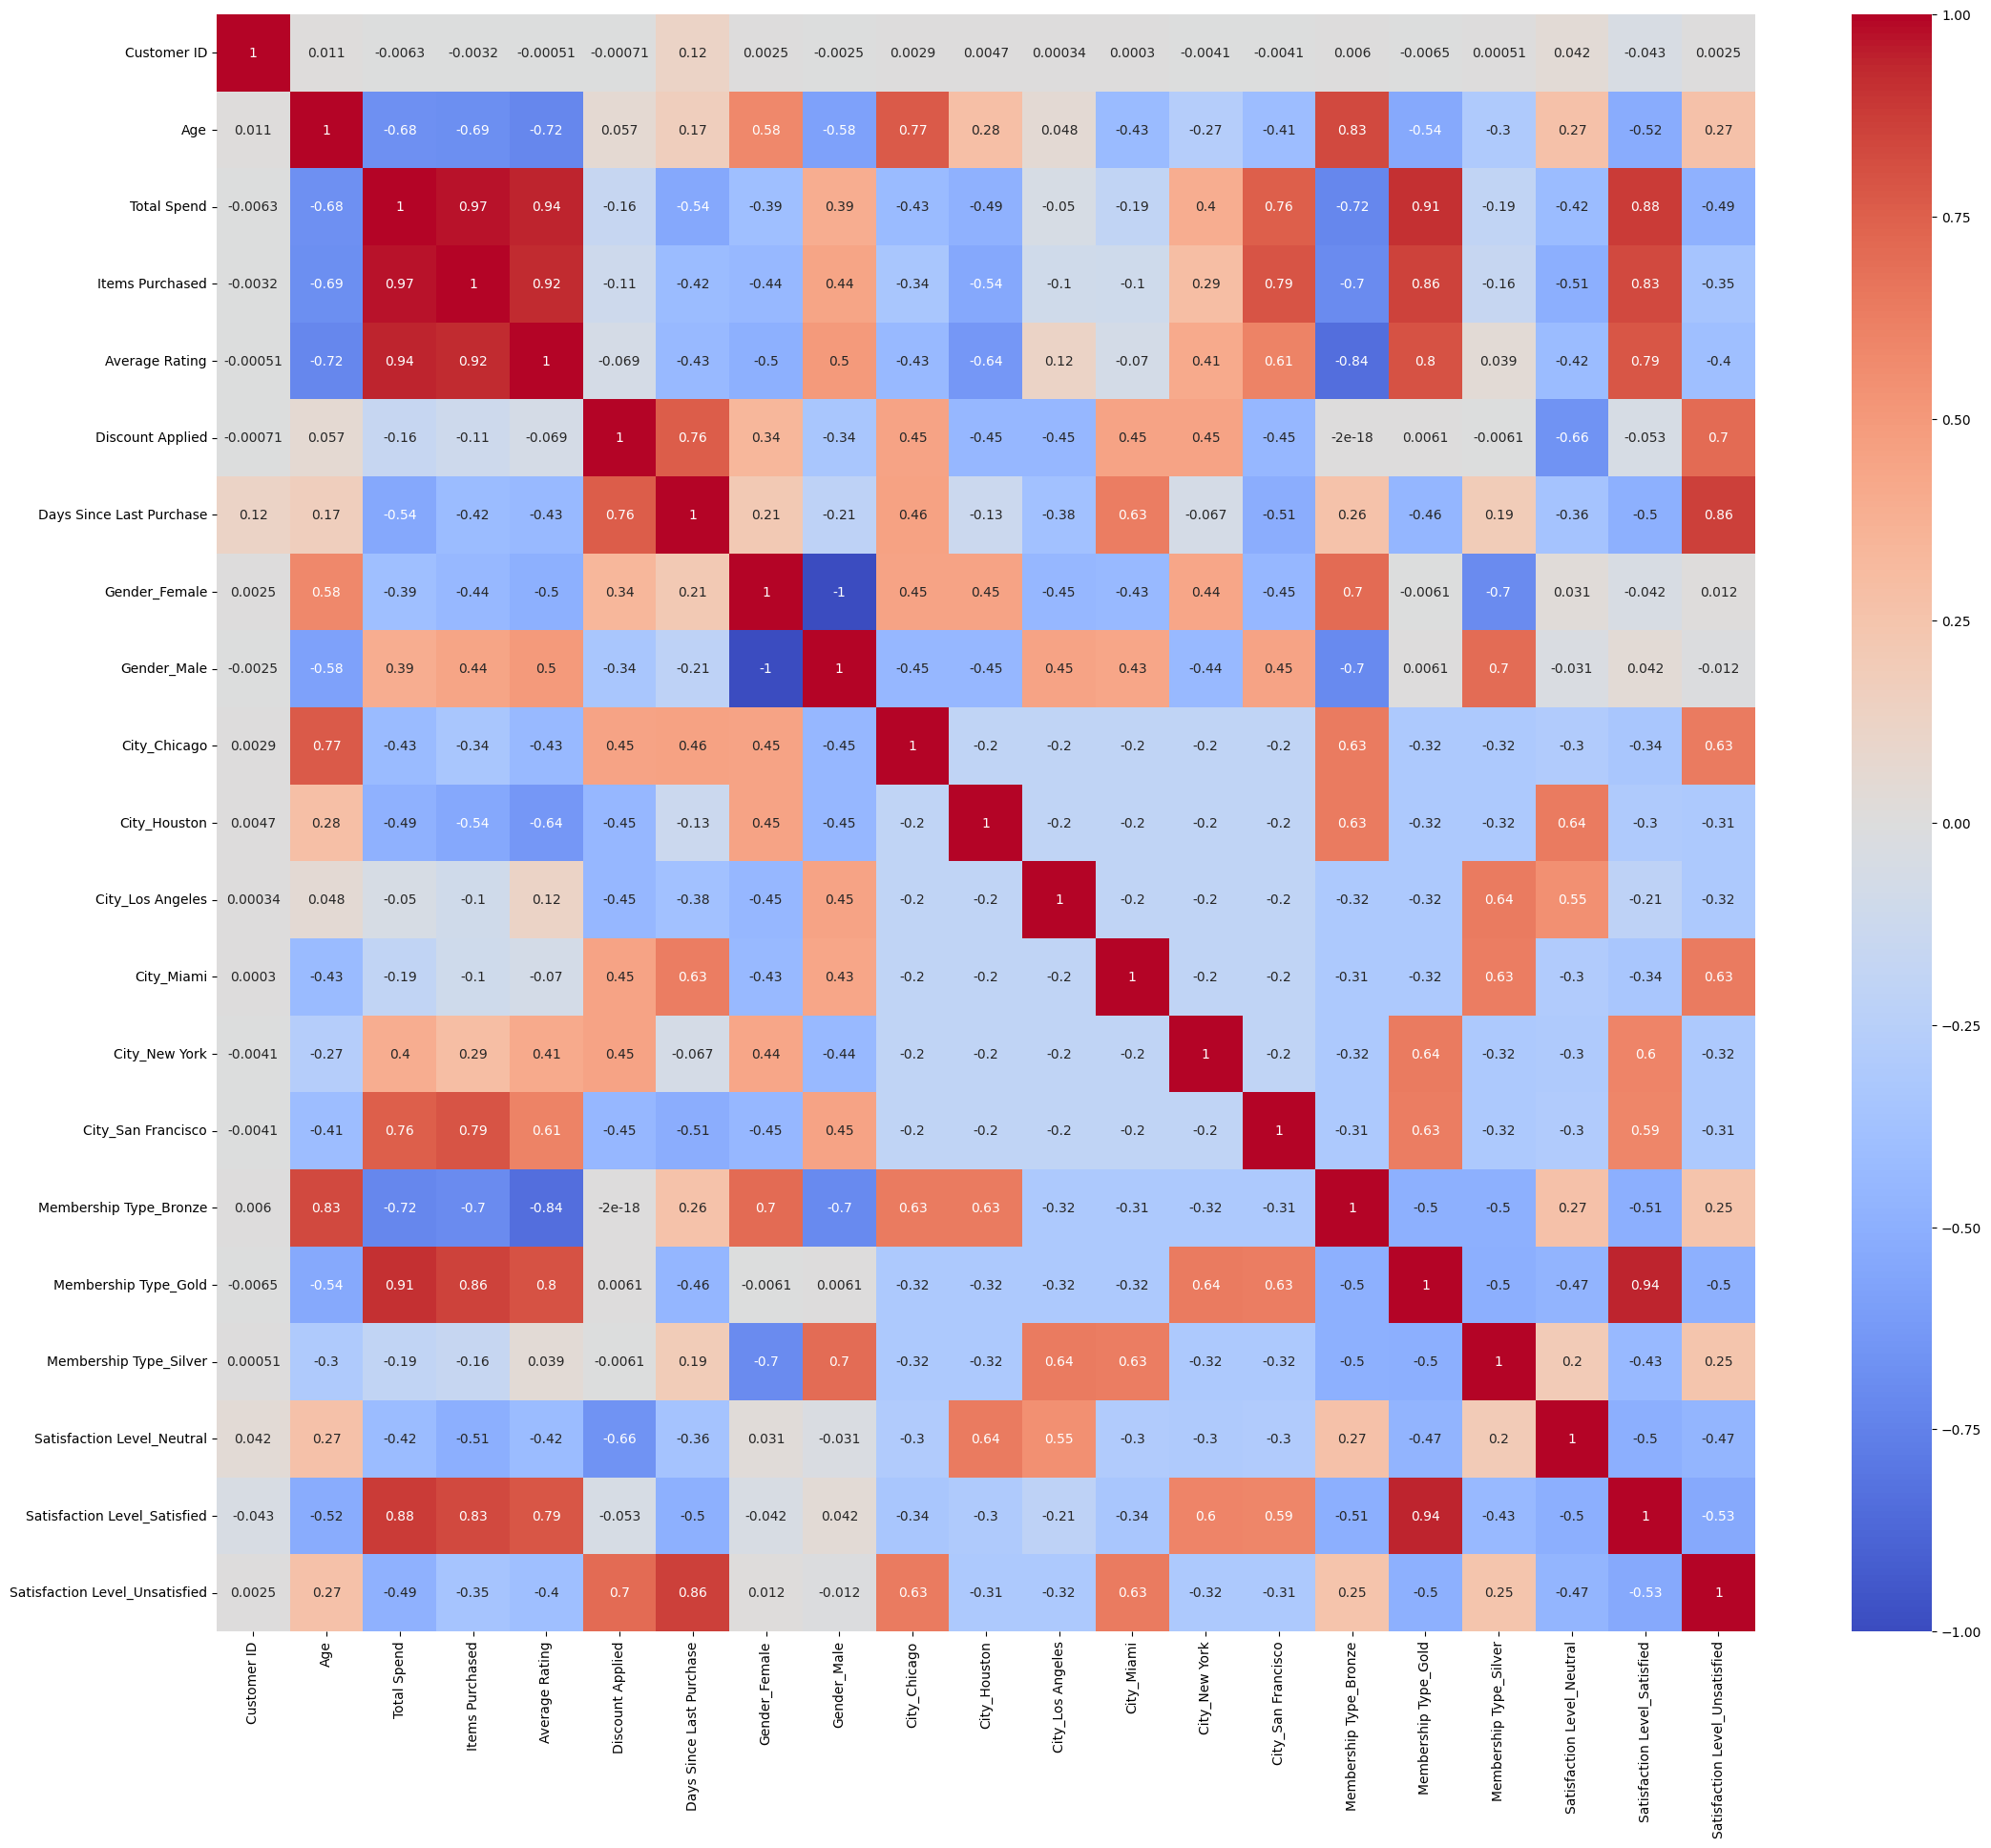

In [48]:
plt.figure(figsize=(26, 22))
corr=df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [49]:
scaler=StandardScaler()
scaler.fit(df[numerical_cols])
df[numerical_cols]=scaler.transform(df[numerical_cols])

In [50]:
df.head()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Gender_Female,Gender_Male,City_Chicago,...,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Bronze,Membership Type_Gold,Membership Type_Silver,Satisfaction Level_Neutral,Satisfaction Level_Satisfied,Satisfaction Level_Unsatisfied
0,-1.727109,-0.945152,0.760130,0.337346,1.001981,1.0,-0.118359,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-1.717212,0.082826,-0.179459,-0.385538,0.139479,-1.0,-0.639907,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,-1.707314,1.933185,-0.925570,-0.867461,-1.068024,1.0,1.148256,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.697417,-0.739557,1.756144,1.542153,1.174482,-1.0,-1.086947,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.687519,-1.356343,-0.345692,0.096385,-0.033022,1.0,2.116844,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [51]:
df = df.drop(columns=['Customer ID'])

In [52]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

In [53]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

<function matplotlib.pyplot.show(close=None, block=None)>

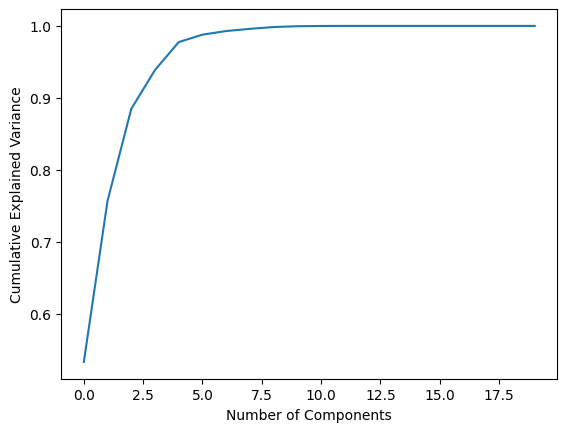

In [54]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show

In [55]:
pca_2=PCA(n_components=2)
X_train_pca_2=pca_2.fit_transform(X_train)

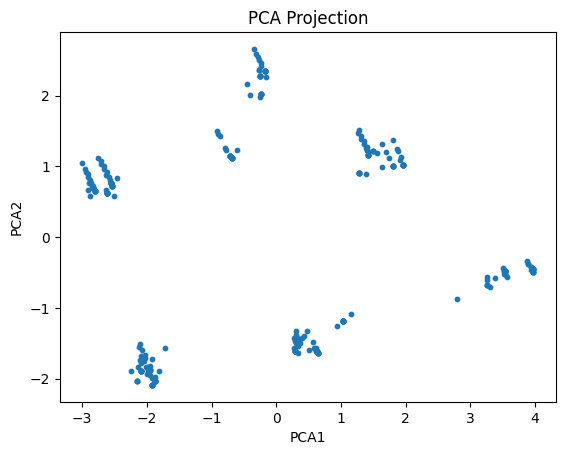

In [56]:
plt.scatter(X_train_pca_2[:,0], X_train_pca_2[:,1], s=10)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA Projection")
plt.show()

In [57]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)

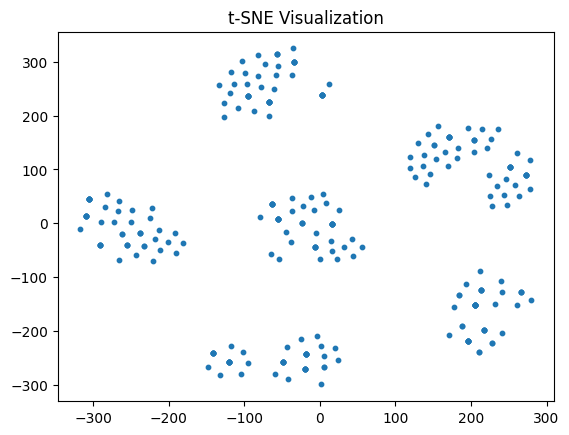

In [58]:
plt.scatter(X_train_tsne[:,0], X_train_tsne[:,1], s=10)
plt.title("t-SNE Visualization")
plt.show()

In [59]:
umap_model = umap.UMAP( n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_train_umap = umap_model.fit_transform(X_train)

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


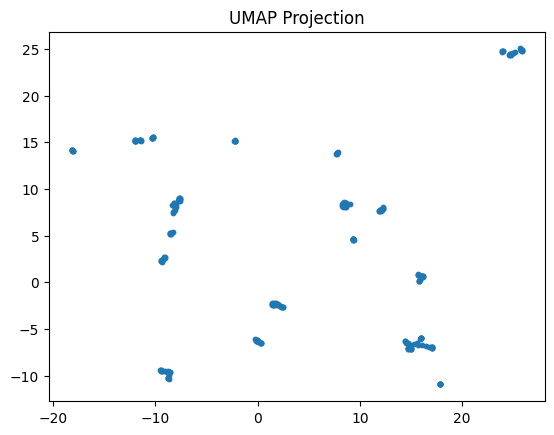

In [60]:
plt.scatter(X_train_umap[:,0], X_train_umap[:,1], s=10)
plt.title("UMAP Projection")
plt.show()

In [61]:
features = ['Age', 'Total Spend', 'Days Since Last Purchase', 'Discount Applied', 'Membership Type_Bronze', 
            'Membership Type_Gold',	'Membership Type_Silver']
X = X_train[features]

In [62]:
features_2 = ['Age', 'Total Spend', 'Days Since Last Purchase', 'Discount Applied', 'Membership Type_Bronze', 
            'Membership Type_Gold',	'Membership Type_Silver', 'Satisfaction Level_Neutral', 'Satisfaction Level_Satisfied', 
            'Satisfaction Level_Unsatisfied', 'Items Purchased', 'Average Rating']
X_2 = X_train[features_2]

In [63]:
sil_scores = []
db_scores  = []
ch_scores  = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

In [64]:
sil_scores_2 = []
db_scores_2  = []
ch_scores_2  = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_2)
    sil_scores_2.append(silhouette_score(X_2, labels))
    db_scores_2.append(davies_bouldin_score(X_2, labels))
    ch_scores_2.append(calinski_harabasz_score(X_2, labels))

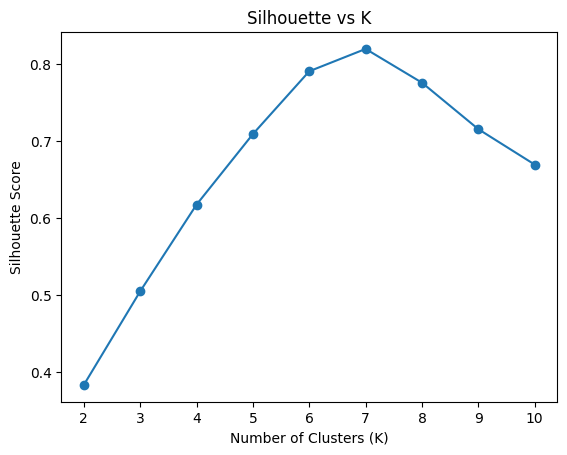

In [65]:
plt.plot(K, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs K")
plt.show()

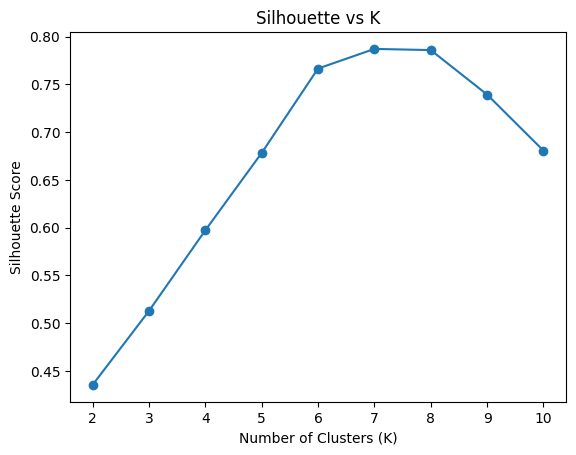

In [66]:
plt.plot(K, sil_scores_2, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs K")
plt.show()

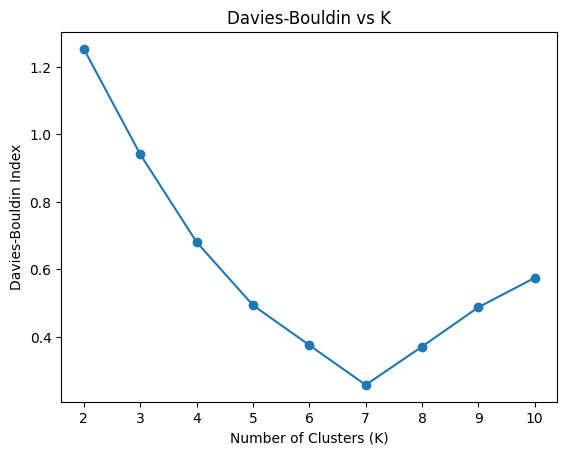

In [67]:
plt.plot(K, db_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin vs K")
plt.show()

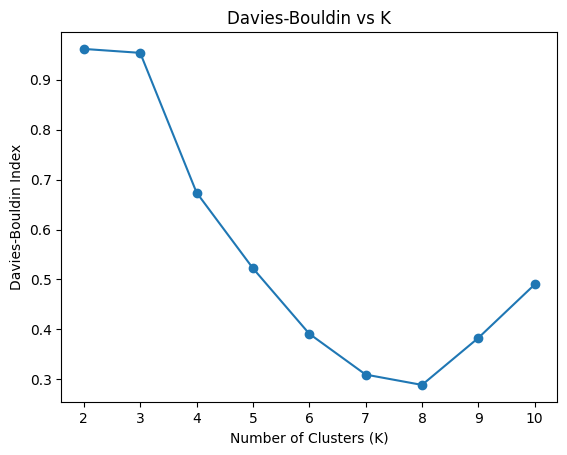

In [68]:
plt.plot(K, db_scores_2, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin vs K")
plt.show()

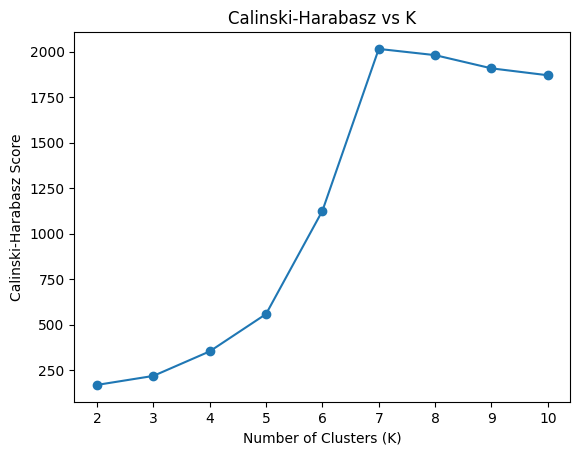

In [69]:
plt.plot(K, ch_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz vs K")
plt.show()

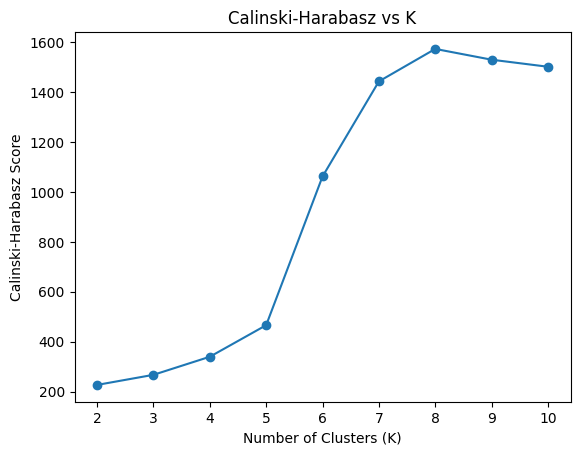

In [70]:
plt.plot(K, ch_scores_2, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz vs K")
plt.show()

In [77]:
kmeans_1 = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_labels_1 = kmeans_1.fit_predict(X)
X_train['Cluster_kmeans_feature1'] = kmeans_labels_1
cluster_sizes = X_train['Cluster_kmeans_feature1'].value_counts().sort_index()
cluster_pct = cluster_sizes / len(X_train) * 100
print(pd.concat([cluster_sizes, cluster_pct], axis=1)
      .rename(columns={0: 'Count', 1: 'Percentage'}))

                         count      count
Cluster_kmeans_feature1                  
0                           28  10.000000
1                           46  16.428571
2                           43  15.357143
3                           46  16.428571
4                           53  18.928571
5                           47  16.785714
6                           17   6.071429


In [78]:
kmeans_2 = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_labels_2 = kmeans_2.fit_predict(X_2)
X_train['Cluster_kmeans_feature2'] = kmeans_labels_2
cluster_sizes = X_train['Cluster_kmeans_feature2'].value_counts().sort_index()
cluster_pct = cluster_sizes / len(X_train) * 100
print(pd.concat([cluster_sizes, cluster_pct], axis=1)
      .rename(columns={0: 'Count', 1: 'Percentage'}))

                         count      count
Cluster_kmeans_feature2                  
0                           28  10.000000
1                           46  16.428571
2                           46  16.428571
3                           53  18.928571
4                           43  15.357143
5                           40  14.285714
6                           17   6.071429
7                            7   2.500000


In [79]:
test_labels_kmeans_1 = kmeans_1.predict(X_test[features])
print("Silhouette Score for Training Data:", silhouette_score(X, kmeans_labels_1))
print("Silhouette Score for Test Data:", silhouette_score(X_test[features], test_labels_kmeans_1))
print("Davies-Bouldin Score for Training Data:", davies_bouldin_score(X, kmeans_labels_1))
print("Davies-Bouldin Score for Test Data:", davies_bouldin_score(X_test[features], test_labels_kmeans_1))

Silhouette Score for Training Data: 0.8199391818756279
Silhouette Score for Test Data: 0.8194878758230727
Davies-Bouldin Score for Training Data: 0.25787774637019256
Davies-Bouldin Score for Test Data: 0.2547059673000182


In [81]:
test_labels_kmeans_2 = kmeans_2.predict(X_test[features_2])
print("Silhouette Score for Training Data:", silhouette_score(X, kmeans_labels_2))
print("Silhouette Score for Test Data:", silhouette_score(X_test[features_2], test_labels_kmeans_2))
print("Davies-Bouldin Score for Training Data:", davies_bouldin_score(X, kmeans_labels_2))
print("Davies-Bouldin Score for Test Data:", davies_bouldin_score(X_test[features_2], test_labels_kmeans_2))

Silhouette Score for Training Data: 0.725084488936799
Silhouette Score for Test Data: 0.765098801606188
Davies-Bouldin Score for Training Data: 0.41482623304064925
Davies-Bouldin Score for Test Data: 0.28732802961368564


In [82]:
X_train['KMeans_Cluster1'] = kmeans_labels_1
X_train['KMeans_Cluster2'] = kmeans_labels_2


In [83]:
cluster_profile = X_train.groupby('KMeans_Cluster1')[
    ['Age',
     'Total Spend',
     'Days Since Last Purchase',
     'Discount Applied']
].mean()
print(cluster_profile)

                      Age  Total Spend  Days Since Last Purchase  \
KMeans_Cluster1                                                    
0               -1.393057    -0.391982                  1.962508   
1                0.632570    -1.102542                 -0.278711   
2               -0.906902     1.708557                 -1.138929   
3               -0.601003     0.886395                 -0.144275   
4                1.727590    -0.954759                  1.032981   
5                0.091574    -0.110407                 -0.833307   
6               -0.328365    -0.481011                  0.587264   

                 Discount Applied  
KMeans_Cluster1                    
0                             1.0  
1                            -1.0  
2                            -1.0  
3                             1.0  
4                             1.0  
5                            -1.0  
6                             1.0  


In [84]:
cluster_profile = X_train.groupby('KMeans_Cluster2')[
    ['Age',
     'Total Spend',
     'Days Since Last Purchase',
     'Discount Applied']
].mean()
print(cluster_profile)

                      Age  Total Spend  Days Since Last Purchase  \
KMeans_Cluster2                                                    
0               -1.393057    -0.391982                  1.962508   
1                0.632570    -1.102542                 -0.278711   
2               -0.601003     0.886395                 -0.144275   
3                1.727590    -0.954759                  1.032981   
4               -0.906902     1.708557                 -1.138929   
5                0.129085    -0.121955                 -0.816860   
6               -0.328365    -0.481011                  0.587264   
7               -0.122770    -0.044422                 -0.927290   

                 Discount Applied  
KMeans_Cluster2                    
0                             1.0  
1                            -1.0  
2                             1.0  
3                             1.0  
4                            -1.0  
5                            -1.0  
6                             1

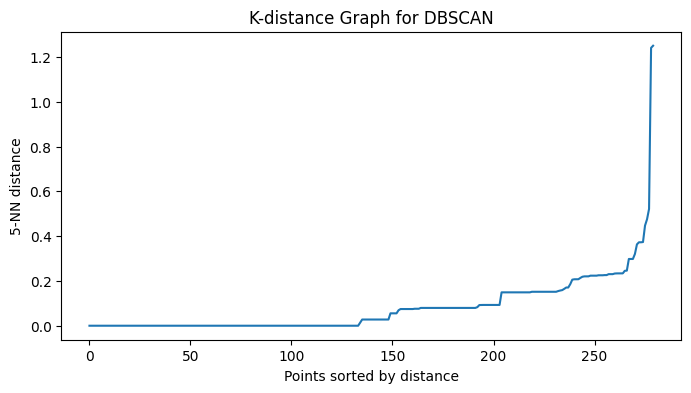

In [85]:
neighbors_1=NearestNeighbors(n_neighbors=5)
neighbors_fit_1=neighbors_1.fit(X)
distances_1, indices_1=neighbors_fit_1.kneighbors(X)
distances_1 = np.sort(distances_1[:, 4])
plt.figure(figsize=(8, 4))
plt.plot(distances_1)
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN distance")
plt.title("K-distance Graph for DBSCAN")
plt.show()

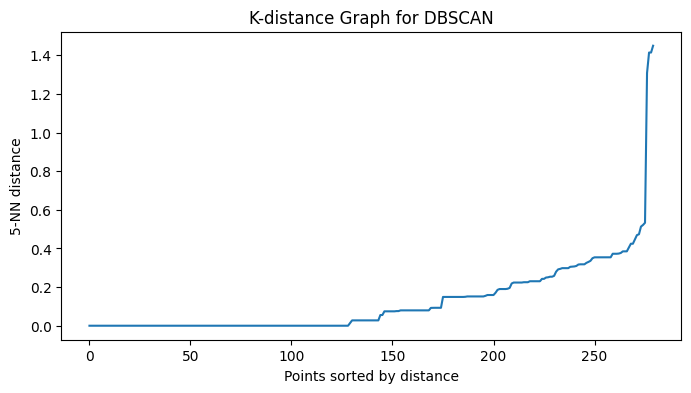

In [86]:
neighbors_2=NearestNeighbors(n_neighbors=5)
neighbors_fit_2=neighbors_2.fit(X_2)
distances_2, indices_2=neighbors_fit_2.kneighbors(X_2)
distances_2 = np.sort(distances_2[:, 4])
plt.figure(figsize=(8, 4))
plt.plot(distances_2)
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN distance")
plt.title("K-distance Graph for DBSCAN")
plt.show()

In [87]:
dbscan_1=DBSCAN(eps=0.8, min_samples=5)
dbscan_labels_1=dbscan_1.fit_predict(X)

In [88]:
unique_labels_1, counts_1 = np.unique(dbscan_labels_1, return_counts=True)
dict(zip(unique_labels_1, counts_1))

{np.int64(-1): np.int64(2),
 np.int64(0): np.int64(46),
 np.int64(1): np.int64(46),
 np.int64(2): np.int64(28),
 np.int64(3): np.int64(53),
 np.int64(4): np.int64(46),
 np.int64(5): np.int64(42),
 np.int64(6): np.int64(17)}

In [89]:
dbscan_2=DBSCAN(eps=0.8, min_samples=5)
dbscan_labels_2=dbscan_2.fit_predict(X_2)

In [90]:
unique_labels_2, counts_2 = np.unique(dbscan_labels_2, return_counts=True)
dict(zip(unique_labels_2, counts_2))

{np.int64(-1): np.int64(4),
 np.int64(0): np.int64(39),
 np.int64(1): np.int64(46),
 np.int64(2): np.int64(28),
 np.int64(3): np.int64(53),
 np.int64(4): np.int64(44),
 np.int64(5): np.int64(42),
 np.int64(6): np.int64(17),
 np.int64(7): np.int64(7)}

In [91]:
print("Silhouette Score for Training Data:", silhouette_score(X, dbscan_labels_1))
print("Davies-Bouldin Score for Training Data:", davies_bouldin_score(X, dbscan_labels_1))

Silhouette Score for Training Data: 0.8115649122841537
Davies-Bouldin Score for Training Data: 0.8733116775065193


In [92]:
print("Silhouette Score for Training Data:", silhouette_score(X, dbscan_labels_2))
print("Davies-Bouldin Score for Training Data:", davies_bouldin_score(X, dbscan_labels_2))

Silhouette Score for Training Data: 0.7163087738121807
Davies-Bouldin Score for Training Data: 1.1423014025245477


In [93]:
X_train['DBSCAN_Cluster1'] = dbscan_labels_1
cluster_profile1 = X_train[X_train['DBSCAN_Cluster1'] != -1] \
    .groupby('DBSCAN_Cluster1')[features].mean()
cluster_profile1

,Age,Total Spend,Days Since Last Purchase,Discount Applied,Membership Type_Bronze,Membership Type_Gold,Membership Type_Silver
DBSCAN_Cluster1,,,,,,,
0,0.123051,-0.108930,-0.834272,-1.0,0.0,0.0,1.0
1,-0.601003,0.886395,-0.144275,1.0,0.0,1.0,0.0
2,-1.393057,-0.391982,1.962508,1.0,0.0,0.0,1.0
3,1.727590,-0.954759,1.032981,1.0,1.0,0.0,0.0
4,0.632570,-1.102542,-0.278711,-1.0,1.0,0.0,0.0
5,-0.940257,1.711343,-1.138393,-1.0,0.0,1.0,0.0
6,-0.328365,-0.481011,0.587264,1.0,0.0,0.0,1.0


In [94]:
X_train['DBSCAN_Cluster2'] = dbscan_labels_2
cluster_profile2 = X_train[X_train['DBSCAN_Cluster2'] != -1] \
    .groupby('DBSCAN_Cluster2')[features].mean()
cluster_profile2

,Age,Total Spend,Days Since Last Purchase,Discount Applied,Membership Type_Bronze,Membership Type_Gold,Membership Type_Silver
DBSCAN_Cluster2,,,,,,,
0,0.167173,-0.120509,-0.817577,-1.0,0.0,0.0,1.0
1,-0.601003,0.886395,-0.144275,1.0,0.0,1.0,0.0
2,-1.393057,-0.391982,1.962508,1.0,0.0,0.0,1.0
3,1.727590,-0.954759,1.032981,1.0,1.0,0.0,0.0
4,0.629523,-1.099906,-0.275840,-1.0,1.0,0.0,0.0
5,-0.940257,1.711343,-1.138393,-1.0,0.0,1.0,0.0
6,-0.328365,-0.481011,0.587264,1.0,0.0,0.0,1.0
7,-0.122770,-0.044422,-0.927290,-1.0,0.0,0.0,1.0


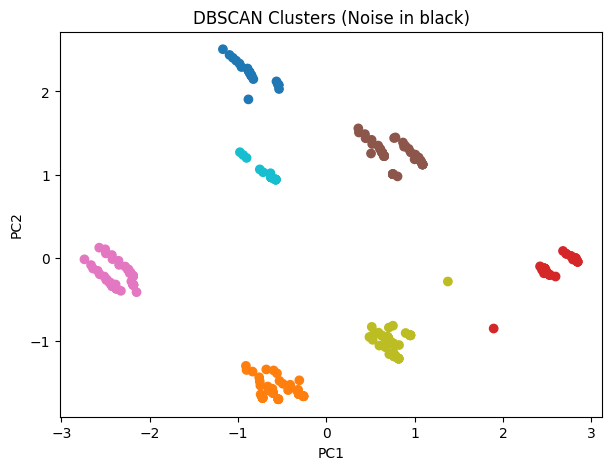

In [57]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (Noise in black)")
plt.show()

In [95]:
bic_scores1 = []
aic_scores1 = []
K = range(2, 11)
for k in K:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X)
    bic_scores1.append(gmm.bic(X))
    aic_scores1.append(gmm.aic(X))

In [97]:
bic_scores2 = []
aic_scores2 = []
K = range(2, 11)
for k in K:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X_2)
    bic_scores2.append(gmm.bic(X_2))
    aic_scores2.append(gmm.aic(X_2))

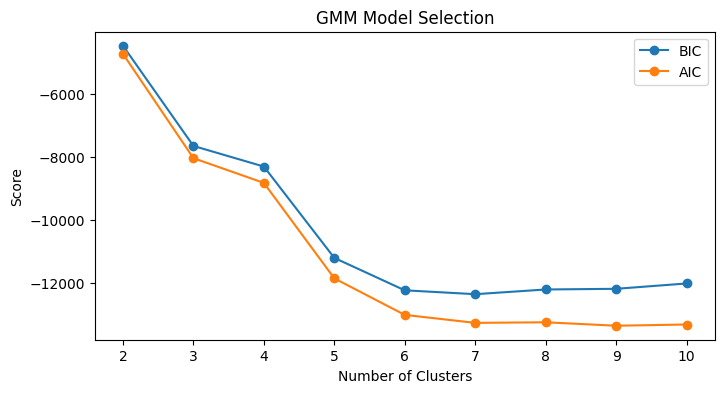

In [96]:
plt.figure(figsize=(8,4))
plt.plot(K, bic_scores1, marker='o', label='BIC')
plt.plot(K, aic_scores1, marker='o', label='AIC')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("GMM Model Selection")
plt.legend()
plt.show()

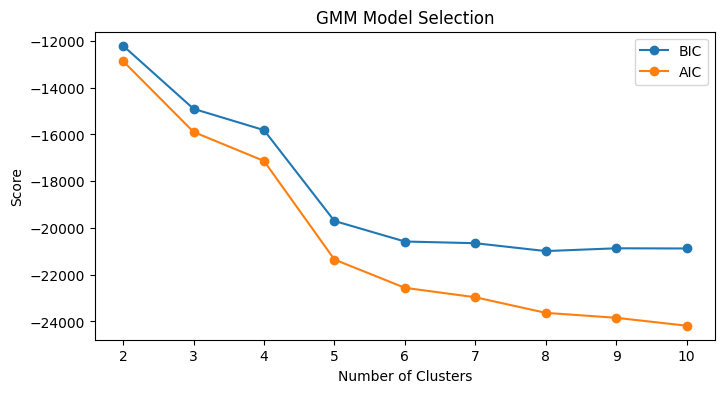

In [98]:
plt.figure(figsize=(8,4))
plt.plot(K, bic_scores2, marker='o', label='BIC')
plt.plot(K, aic_scores2, marker='o', label='AIC')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("GMM Model Selection")
plt.legend()
plt.show()

In [113]:
gmm_1 = GaussianMixture(
    n_components=7,        
    covariance_type='full',
    random_state=42
)
gmm_labels_1 = gmm_1.fit_predict(X)
X_train['GMM_Cluster1'] = gmm_labels_1

In [114]:
test_labels_gmm_1 = gmm_1.predict(X_test[features])
print("Silhouette Score for Training Data:", silhouette_score(X, gmm_labels_1))
print("Silhouette Score for Test Data:", silhouette_score(X_test[features], test_labels_gmm_1))
print("Davies-Bouldin Score for Training Data:", davies_bouldin_score(X, gmm_labels_1))
print("Davies-Bouldin Score for Test Data:", davies_bouldin_score(X_test[features], test_labels_gmm_1))

Silhouette Score for Training Data: 0.8199391818756279
Silhouette Score for Test Data: 0.8194878758230727
Davies-Bouldin Score for Training Data: 0.25787774637019256
Davies-Bouldin Score for Test Data: 0.2547059673000182


In [115]:
gmm_2 = GaussianMixture(
    n_components=7,        
    covariance_type='full',
    random_state=42
)
gmm_labels_2 = gmm_2.fit_predict(X_2)
X_train['GMM_Cluster2'] = gmm_labels_2

In [116]:
test_labels_gmm_2 = gmm_2.predict(X_test[features_2])
print("Silhouette Score for Training Data:", silhouette_score(X_2, gmm_labels_2))
print("Silhouette Score for Test Data:", silhouette_score(X_test[features_2], test_labels_gmm_2))
print("Davies-Bouldin Score for Training Data:", davies_bouldin_score(X_2, gmm_labels_2))
print("Davies-Bouldin Score for Test Data:", davies_bouldin_score(X_test[features_2], test_labels_gmm_2))

Silhouette Score for Training Data: 0.7872440868289183
Silhouette Score for Test Data: 0.7837705704241925
Davies-Bouldin Score for Training Data: 0.30972710565028755
Davies-Bouldin Score for Test Data: 0.310291216388965


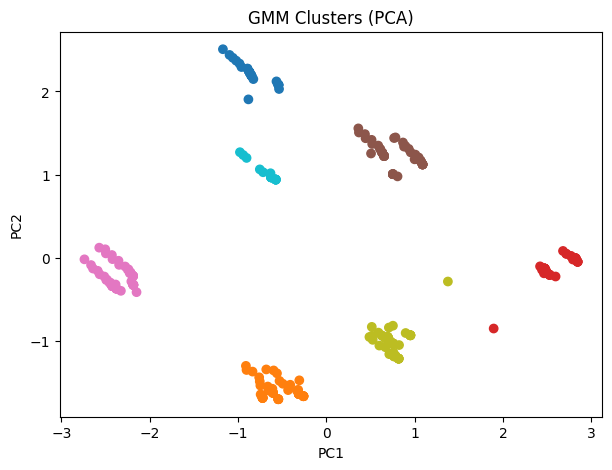

In [111]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels_1, cmap='tab10')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters (PCA)")
plt.show()

In [117]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 228 to 102
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             280 non-null    float64
 1   Total Spend                     280 non-null    float64
 2   Items Purchased                 280 non-null    float64
 3   Average Rating                  280 non-null    float64
 4   Discount Applied                280 non-null    float64
 5   Days Since Last Purchase        280 non-null    float64
 6   Gender_Female                   280 non-null    float64
 7   Gender_Male                     280 non-null    float64
 8   City_Chicago                    280 non-null    float64
 9   City_Houston                    280 non-null    float64
 10  City_Los Angeles                280 non-null    float64
 11  City_Miami                      280 non-null    float64
 12  City_New York                   280 non

In [118]:
X_train.to_csv(r"..\data\processed\after_training_ecommerce_data.csv", index=False)